In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

print("libreria cargadas correctamente")

df = pd.read_csv('../data/survey_results_public.csv')

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

for col in df.columns:
    print(col)

libreria cargadas correctamente


C:\Users\Drois\AppData\Local\Temp\ipykernel_18820\2093484425.py:11: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/survey_results_public.csv')


Filas: 49191
Columnas: 172
ResponseId
MainBranch
Age
EdLevel
Employment
EmploymentAddl
WorkExp
LearnCodeChoose
LearnCode
LearnCodeAI
AILearnHow
YearsCode
DevType
OrgSize
ICorPM
RemoteWork
PurchaseInfluence
TechEndorseIntro
TechEndorse_1
TechEndorse_2
TechEndorse_3
TechEndorse_4
TechEndorse_5
TechEndorse_6
TechEndorse_7
TechEndorse_8
TechEndorse_9
TechEndorse_13
TechEndorse_13_TEXT
TechOppose_1
TechOppose_2
TechOppose_3
TechOppose_5
TechOppose_7
TechOppose_9
TechOppose_11
TechOppose_13
TechOppose_16
TechOppose_15
TechOppose_15_TEXT
Industry
JobSatPoints_1
JobSatPoints_2
JobSatPoints_3
JobSatPoints_4
JobSatPoints_5
JobSatPoints_6
JobSatPoints_7
JobSatPoints_8
JobSatPoints_9
JobSatPoints_10
JobSatPoints_11
JobSatPoints_13
JobSatPoints_14
JobSatPoints_15
JobSatPoints_16
JobSatPoints_15_TEXT
AIThreat
NewRole
ToolCountWork
ToolCountPersonal
Country
Currency
CompTotal
LanguageChoice
LanguageHaveWorkedWith
LanguageWantToWorkWith
LanguageAdmired
LanguagesHaveEntry
LanguagesWantEntry
DatabaseCho

In [10]:
# seleccionamos las columnas que usaremos
columnas = ['Country', 'WorkExp', 'ConvertedCompYearly', 
            'EdLevel', 'DevType', 'LanguageHaveWorkedWith',
            'YearsCode', 'RemoteWork', 'AISelect']

df_limpio = df[columnas].copy()

# eliminamos filas sin salario
df_limpio = df_limpio.dropna(subset=['ConvertedCompYearly'])

# Filtramos salarios realistas (entre 10.000 y 400.000 USD anuales)
df_limpio = df_limpio[
    (df_limpio['ConvertedCompYearly'] > 10000) & 
    (df_limpio['ConvertedCompYearly'] < 400000)
]

print(f"Registros después de limpiar: {len(df_limpio)}")
print(f"\nValores nulos por columna:")
print(df_limpio.isnull().sum())

Registros después de limpiar: 21039

Valores nulos por columna:
Country                      0
WorkExp                    246
ConvertedCompYearly          0
EdLevel                     14
DevType                      0
LanguageHaveWorkedWith    1341
YearsCode                   66
RemoteWork                2311
AISelect                   532
dtype: int64


In [11]:
# Rellenamos nulos con valores por defecto
df_limpio['WorkExp'] = df_limpio['WorkExp'].fillna(df_limpio['WorkExp'].median())
df_limpio['YearsCode'] = df_limpio['YearsCode'].fillna(df_limpio['YearsCode'].median())
df_limpio['EdLevel'] = df_limpio['EdLevel'].fillna('No especificado')
df_limpio['RemoteWork'] = df_limpio['RemoteWork'].fillna('No especificado')
df_limpio['AISelect'] = df_limpio['AISelect'].fillna('No especificado')
df_limpio['LanguageHaveWorkedWith'] = df_limpio['LanguageHaveWorkedWith'].fillna('No especificado')

print("Nulos después de limpiar:")
print(df_limpio.isnull().sum())
print(f"\nEstadísticas del salario (USD/año):")
print(df_limpio['ConvertedCompYearly'].describe().apply(lambda x: f"${x:,.0f}"))

Nulos después de limpiar:
Country                   0
WorkExp                   0
ConvertedCompYearly       0
EdLevel                   0
DevType                   0
LanguageHaveWorkedWith    0
YearsCode                 0
RemoteWork                0
AISelect                  0
dtype: int64

Estadísticas del salario (USD/año):
count     $21,039
mean      $96,524
std       $64,233
min       $10,024
25%       $50,000
50%       $81,685
75%      $127,616
max      $398,000
Name: ConvertedCompYearly, dtype: str


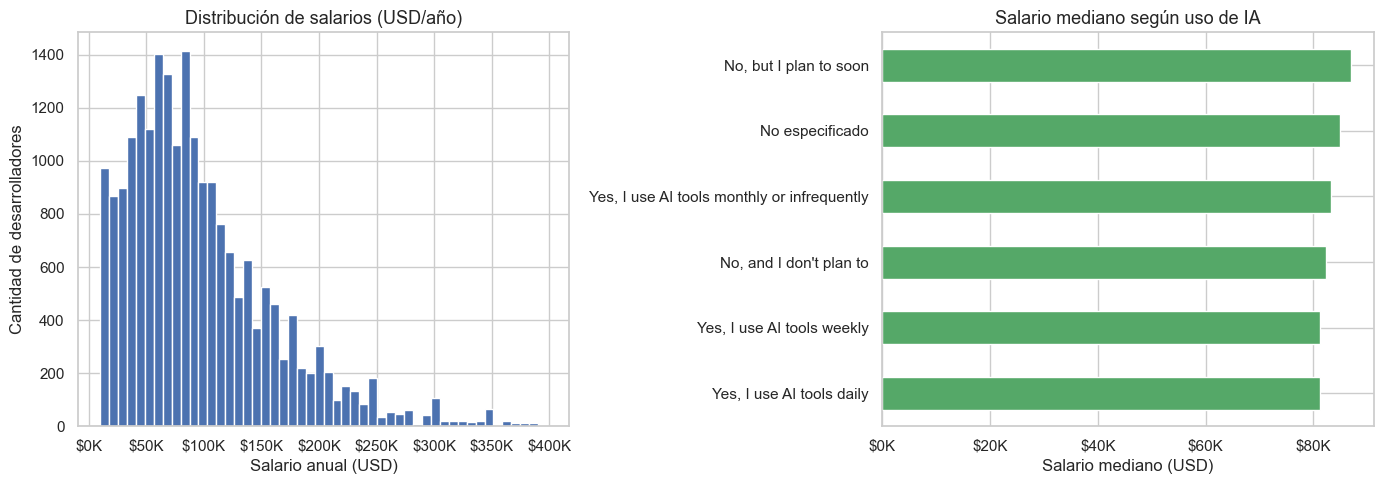

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 - Distribución de salarios
axes[0].hist(df_limpio['ConvertedCompYearly'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de salarios (USD/año)', fontsize=13)
axes[0].set_xlabel('Salario anual (USD)')
axes[0].set_ylabel('Cantidad de desarrolladores')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Gráfico 2 - Salario promedio por uso de IA
salario_ia = df_limpio.groupby('AISelect')['ConvertedCompYearly'].median().sort_values(ascending=True)
salario_ia.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Salario mediano según uso de IA', fontsize=13)
axes[1].set_xlabel('Salario mediano (USD)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

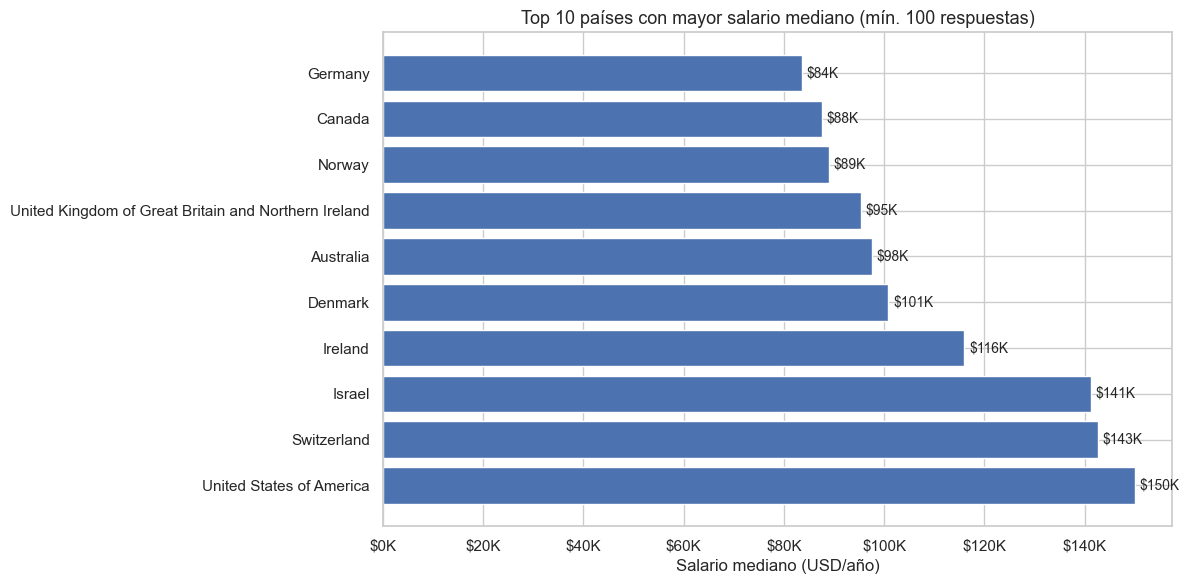


Tabla completa:
                                                   Salario mediano (USD)  \
Country                                                                    
United States of America                                        $150,000   
Switzerland                                                     $142,592   
Israel                                                          $141,188   
Ireland                                                         $116,015   
Denmark                                                         $100,777   
Australia                                                        $97,514   
United Kingdom of Great Britain and Northern Ir...               $95,299   
Norway                                                           $88,945   
Canada                                                           $87,550   
Germany                                                          $83,531   

                                                    Respuestas  
Count

In [13]:
# Top 10 paises con mayor salario mediano
top_paises = (df_limpio.groupby('Country')['ConvertedCompYearly']
              .agg(['median', 'count'])
              .query('count >= 100')  # Solo paises con al menos 100 respuestas
              .sort_values('median', ascending=False)
              .head(10))

plt.figure(figsize=(12, 6))
bars = plt.barh(top_paises.index, top_paises['median'], color='#4C72B0')
plt.title('Top 10 países con mayor salario mediano (mín. 100 respuestas)', fontsize=13)
plt.xlabel('Salario mediano (USD/año)')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Agregar etiquetas con el valor exacto
for bar, val in zip(bars, top_paises['median']):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nTabla completa:")
top_paises.columns = ['Salario mediano (USD)', 'Respuestas']
top_paises['Salario mediano (USD)'] = top_paises['Salario mediano (USD)'].apply(lambda x: f'${x:,.0f}')
print(top_paises)

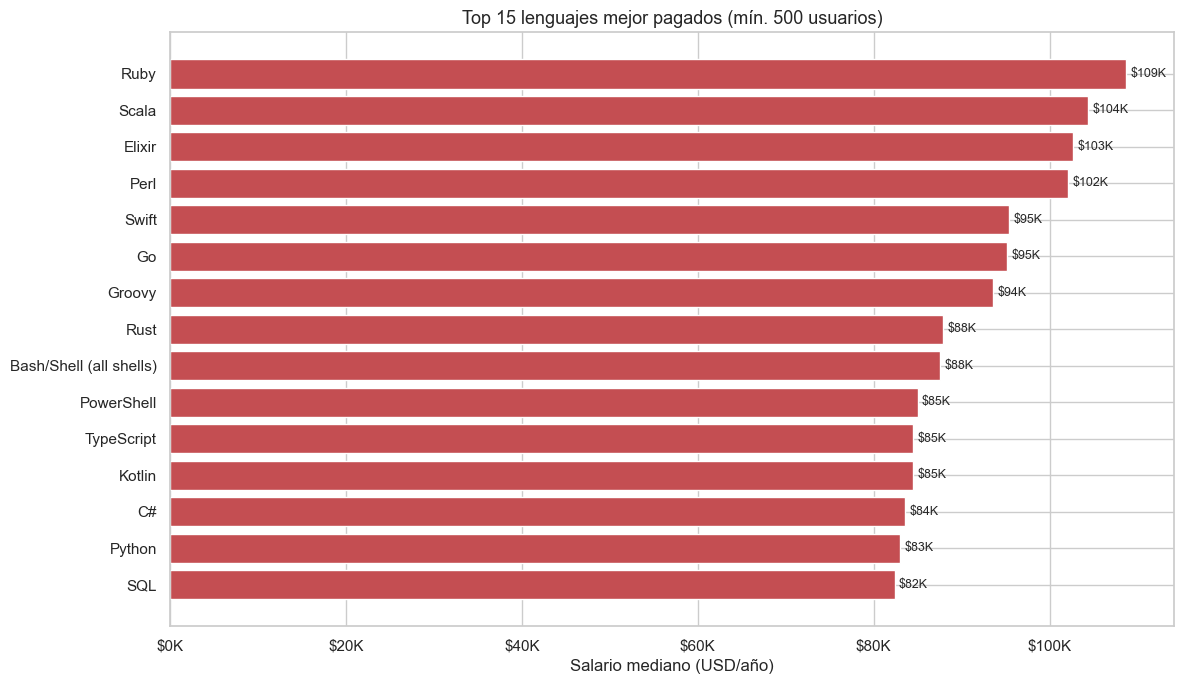

In [14]:
# Cada fila tiene varios lenguajes separados por ";"
lenguajes_salario = []

for _, row in df_limpio.iterrows():
    if row['LanguageHaveWorkedWith'] != 'No especificado':
        for lang in row['LanguageHaveWorkedWith'].split(';'):
            lenguajes_salario.append({
                'Lenguaje': lang.strip(),
                'Salario': row['ConvertedCompYearly']
            })

df_lang = pd.DataFrame(lenguajes_salario)

# Top 15 lenguajes con mas de 500 respuestas
top_lang = (df_lang.groupby('Lenguaje')['Salario']
            .agg(['median', 'count'])
            .query('count >= 500')
            .sort_values('median', ascending=True)
            .tail(15))

plt.figure(figsize=(12, 7))
bars = plt.barh(top_lang.index, top_lang['median'], color='#C44E52')
plt.title('Top 15 lenguajes mejor pagados (mín. 500 usuarios)', fontsize=13)
plt.xlabel('Salario mediano (USD/año)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

for bar, val in zip(bars, top_lang['median']):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Preparar features para el modelo
df_modelo = df_limpio[['WorkExp', 'YearsCode', 'EdLevel', 
                        'RemoteWork', 'AISelect', 'ConvertedCompYearly']].copy()

# Convertir columnas de texto a numeros
le = LabelEncoder()
for col in ['EdLevel', 'RemoteWork', 'AISelect']:
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))

# Convertir YearsCode a numero
df_modelo['YearsCode'] = pd.to_numeric(df_modelo['YearsCode'], errors='coerce')
df_modelo['YearsCode'] = df_modelo['YearsCode'].fillna(df_modelo['YearsCode'].median())

# Separar features 
X = df_modelo.drop('ConvertedCompYearly', axis=1)
y = df_modelo['ConvertedCompYearly']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)} registros")
print(f"Datos de prueba: {len(X_test)} registros")
print("\nEntrenando modelo... (puede tardar unos segundos)")

# Entrenar el modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Evaluar
predicciones = modelo.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"\n✓ Modelo entrenado")
print(f"Error promedio: ${mae:,.0f} USD")
print(f"R² score: {r2:.3f}  (1.0 = perfecto, 0 = inútil)")

Datos de entrenamiento: 16831 registros
Datos de prueba: 4208 registros

Entrenando modelo... (puede tardar unos segundos)

✓ Modelo entrenado
Error promedio: $49,196 USD
R² score: -0.016  (1.0 = perfecto, 0 = inútil)


✓ Modelo mejorado entrenado
Error promedio: $46,341 USD
R² score: 0.106


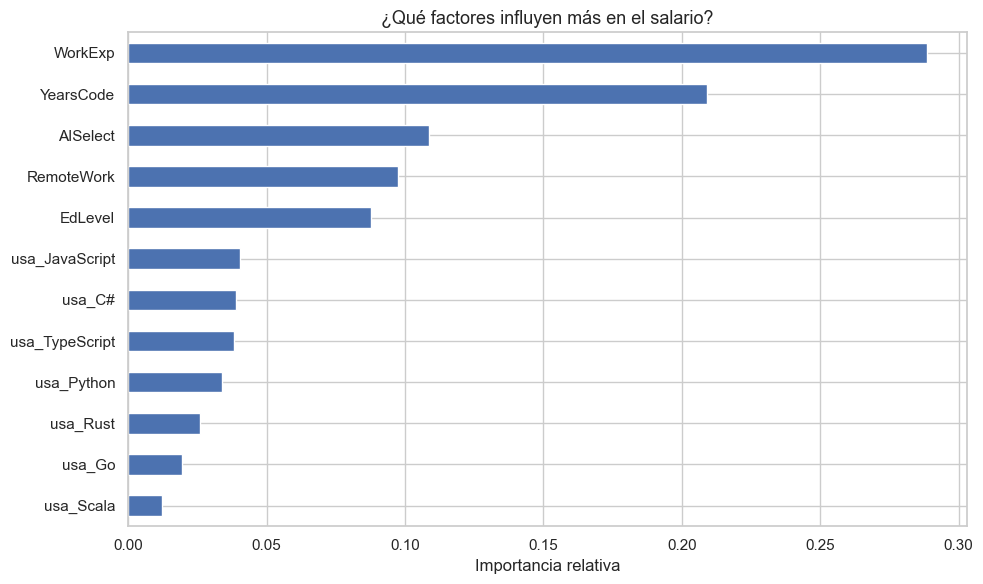

In [16]:
df_modelo2 = df_limpio.copy()

# Crear columnas binarias para lenguajes clave (1 = sabe, 0 = no sabe)
lenguajes_clave = ['Python', 'JavaScript', 'TypeScript', 'Rust', 'Go', 'Scala', 'C#']
for lang in lenguajes_clave:
    df_modelo2[f'usa_{lang}'] = df_modelo2['LanguageHaveWorkedWith'].str.contains(lang, na=False).astype(int)

# Convertir YearsCode a numero
df_modelo2['YearsCode'] = pd.to_numeric(df_modelo2['YearsCode'], errors='coerce')
df_modelo2['YearsCode'] = df_modelo2['YearsCode'].fillna(df_modelo2['YearsCode'].median())

# Encodear columnas categoricas
for col in ['EdLevel', 'RemoteWork', 'AISelect']:
    df_modelo2[col] = LabelEncoder().fit_transform(df_modelo2[col].astype(str))

# Seleccionar features
features = ['WorkExp', 'YearsCode', 'EdLevel', 'RemoteWork', 'AISelect'] + [f'usa_{l}' for l in lenguajes_clave]

X2 = df_modelo2[features]
y2 = df_modelo2['ConvertedCompYearly']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
modelo2.fit(X_train2, y_train2)

pred2 = modelo2.predict(X_test2)
mae2 = mean_absolute_error(y_test2, pred2)
r2_2 = r2_score(y_test2, pred2)

print(f"✓ Modelo mejorado entrenado")
print(f"Error promedio: ${mae2:,.0f} USD")
print(f"R² score: {r2_2:.3f}")

# Importancia de cada feature
importancias = pd.Series(modelo2.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='#4C72B0')
plt.title('¿Qué factores influyen más en el salario?', fontsize=13)
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

In [17]:
def predecir_salario(experiencia_laboral, años_programando, 
                     usa_python=1, usa_javascript=0, usa_typescript=0,
                     usa_rust=0, usa_go=0, usa_scala=0, usa_csharp=0,
                     nivel_educacion=2, trabaja_remoto=2, usa_ia=1):
    
    datos = pd.DataFrame([{
        'WorkExp': experiencia_laboral,
        'YearsCode': años_programando,
        'EdLevel': nivel_educacion,
        'RemoteWork': trabaja_remoto,
        'AISelect': usa_ia,
        'usa_Python': usa_python,
        'usa_JavaScript': usa_javascript,
        'usa_TypeScript': usa_typescript,
        'usa_Rust': usa_rust,
        'usa_Go': usa_go,
        'usa_Scala': usa_scala,
        'usa_C#': usa_csharp
    }])
    
    salario = modelo2.predict(datos)[0]
    return salario

# Simular diferentes perfiles
perfiles = {
    'Junior sin IA (2 años exp)':      predecir_salario(2, 3, usa_ia=0),
    'Junior con IA (2 años exp)':      predecir_salario(2, 3, usa_ia=1),
    'Mid Python+JS (5 años exp)':      predecir_salario(5, 7, usa_python=1, usa_javascript=1),
    'Senior Python+IA (10 años exp)':  predecir_salario(10, 12, usa_python=1, usa_ia=1),
    'Senior C#+IA (10 años exp)':      predecir_salario(10, 12, usa_csharp=1, usa_ia=1),
    'Expert Rust+Go (15 años exp)':    predecir_salario(15, 18, usa_rust=1, usa_go=1),
}

print("=" * 50)
print("  SIMULADOR DE SALARIO - Developer Survey 2025")
print("=" * 50)
for perfil, salario in perfiles.items():
    barra = "█" * int(salario / 5000)
    print(f"\n{perfil}")
    print(f"  ${salario:,.0f} USD/año  {barra}")
print("\n* Basado en 21.039 desarrolladores reales")
print("* Salarios globales en USD - Stack Overflow 2025")

  SIMULADOR DE SALARIO - Developer Survey 2025

Junior sin IA (2 años exp)
  $49,834 USD/año  █████████

Junior con IA (2 años exp)
  $58,204 USD/año  ███████████

Mid Python+JS (5 años exp)
  $54,987 USD/año  ██████████

Senior Python+IA (10 años exp)
  $81,779 USD/año  ████████████████

Senior C#+IA (10 años exp)
  $78,590 USD/año  ███████████████

Expert Rust+Go (15 años exp)
  $144,692 USD/año  ████████████████████████████

* Basado en 21.039 desarrolladores reales
* Salarios globales en USD - Stack Overflow 2025
